# Sigmoid Activation Function

Exploring the Sigmoid function: math, gradient behavior, and implementation (from-scratch and `torch.nn`).

## 1. From-Scratch Implementation (NumPy)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Quick sanity check
x_test = np.array([-2, -1, 0, 1, 2])
print("Sigmoid:", sigmoid(x_test))
print("Derivative:", sigmoid_derivative(x_test))

Matplotlib is building the font cache; this may take a moment.


Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Derivative: [0.10499359 0.19661193 0.25       0.19661193 0.10499359]


## 2. Visualizing Sigmoid and its Derivative

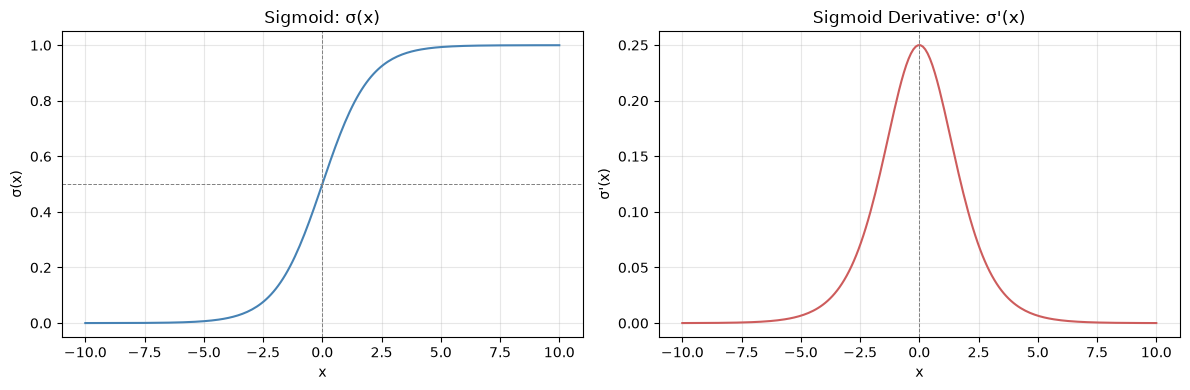

In [4]:
x = np.linspace(-10, 10, 200)
y = sigmoid(x)
dy = sigmoid_derivative(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, y, color='steelblue')
axes[0].set_title("Sigmoid: σ(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("σ(x)")
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, dy, color='indianred')
axes[1].set_title("Sigmoid Derivative: σ'(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("σ'(x)")
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. `torch.nn` Implementation

In [6]:
import torch
import torch.nn as nn

# Using nn.Sigmoid() as a layer
sigmoid_layer = nn.Sigmoid()

x_tensor = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("nn.Sigmoid():", sigmoid_layer(x_tensor))

# Using functional form
print("torch.sigmoid():", torch.sigmoid(x_tensor))

# Autograd confirms our manual derivative
x_grad = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0], requires_grad=True)
y_grad = torch.sigmoid(x_grad)
y_grad.sum().backward()
print("Autograd gradient:", x_grad.grad)

nn.Sigmoid(): tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
torch.sigmoid(): tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
Autograd gradient: tensor([0.1050, 0.1966, 0.2500, 0.1966, 0.1050])


## 4. Observations

- The derivative peaks at **0.25** when `x = 0` and flattens toward 0 as `|x|` increases — this is the vanishing gradient problem in action.
- The manual NumPy derivative matches PyTorch's autograd gradient, confirming the math.
- Sigmoid's output is never zero-centered (always 0 to 1), which affects gradient updates in downstream layers.